In [1]:
import os
import pickle
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

matplotlib.rcParams['text.usetex'] = False

sys.path.insert(0, '..')
from plot_config import MODEL_COLORS, MODEL_DISPLAY_NAMES, MODEL_MARKERS, FONT_SIZES

plt.rcParams.update(FONT_SIZES)

In [2]:
project_root = "../../../.."

# Toggle: set True to load pre-computed results from disk (fast), False to run full data processing
LOAD_PROCESSED_DATA = True

overlap_criteria = 1

_script_name = "cds_level_read_length_across_ablation_models"

_cache_dir = (
    f"{project_root}/data/processed_data/report_results/without_errors/{_script_name}"
)

all_test_accessions = open(f"{project_root}/data/processed_data/genome_partitions/test_partition_accessions.txt").read().splitlines()

genome_info_df = pd.read_csv(f"{project_root}/data/processed_data/dataset_information/genomes_info_with_partitions.csv")
genome_info_df = genome_info_df.set_index('accession')

tt4_families = ['Mycoplasmataceae']

all_genomes = {}
for acc in all_test_accessions:
    if acc in genome_info_df.index:
        row = genome_info_df.loc[acc]
        translation_table = 4 if row['family'] in tt4_families else 11
        all_genomes[acc] = {
            'family': row['family'],
            'domain': row['domain'],
            'gc_content': row['gc_content'],
            'translation_table': translation_table
        }

print(f"Total test accessions: {len(all_test_accessions)}")

read_lengths = [75, 100, 150, 300, 700, 1000]

model_names = ["deep_cds_a2", "deep_cds_a1", "deep_cds"]

models_per_length = {length: model_names for length in read_lengths}

Total test accessions: 215


In [3]:
def calculate_iou(coord1, coord2):
    start1, stop1, rf1 = coord1
    start2, stop2, rf2 = coord2
    if rf1 != rf2:
        return 0.0
    intersection_start = max(start1, start2)
    intersection_stop = min(stop1, stop2)
    if intersection_start >= intersection_stop:
        return 0.0
    intersection_length = intersection_stop - intersection_start
    union_start = min(start1, start2)
    union_stop = max(stop1, stop2)
    union_length = union_stop - union_start
    return intersection_length / union_length if union_length > 0 else 0.0


def find_matching_genes(predicted_coords, actual_coords, overlap_criteria):
    matched_pairs = []
    used_actual = set()
    for pred_idx, pred_coord in enumerate(predicted_coords):
        best_iou = 0.0
        best_actual_idx = -1
        for actual_idx, actual_coord in enumerate(actual_coords):
            if actual_idx in used_actual:
                continue
            iou = calculate_iou(pred_coord, actual_coord)
            if iou >= overlap_criteria and iou > best_iou:
                best_iou = iou
                best_actual_idx = actual_idx
        if best_actual_idx != -1:
            matched_pairs.append((pred_idx, best_actual_idx))
            used_actual.add(best_actual_idx)
    return matched_pairs, len(matched_pairs)


def calculate_metrics(testset_dict, model_preds_dict, all_test_read_names, overlap_criteria):
    total_tp = 0
    total_predicted_genes = 0
    total_actual_genes = 0
    for read_name in all_test_read_names:
        cds_coords_testset = testset_dict.get(read_name, {}).get("cds_coords", [])
        cds_coords_model = model_preds_dict.get(read_name, {}).get("cds_coords", [])
        num_predicted = len(cds_coords_model)
        num_actual = len(cds_coords_testset)
        _, tp_count = find_matching_genes(cds_coords_model, cds_coords_testset, overlap_criteria)
        total_predicted_genes += num_predicted
        total_actual_genes += num_actual
        total_tp += tp_count
    total_fp = total_predicted_genes - total_tp
    total_fn = total_actual_genes - total_tp
    precision = total_tp / total_predicted_genes if total_predicted_genes > 0 else 0.0
    recall = total_tp / total_actual_genes if total_actual_genes > 0 else 0.0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    return {
        'overlap_criteria': overlap_criteria,
        'total_predicted_genes': total_predicted_genes,
        'total_actual_genes': total_actual_genes,
        'total_true_positives': total_tp,
        'total_false_positives': total_fp,
        'total_false_negatives': total_fn,
        'precision': round(precision, 3),
        'recall': round(recall, 3),
        'f1_score': round(f1_score, 3)
    }

In [4]:
def load_testset(test_accession, data_type, project_root=project_root):
    with open(f"{project_root}/data/processed_data/testset_processed/{data_type}/{test_accession}/testset_dict.pkl", "rb") as f:
        testset_dict = pickle.load(f)
    with open(f"{project_root}/data/processed_data/testset_processed/{data_type}/{test_accession}/read_names_list.pkl", "rb") as f:
        read_names_list = pickle.load(f)
    return read_names_list, testset_dict


def load_model_preds(test_accession, data_type, model_name, project_root=project_root):
    pred_paths = {
        "deep_cds_a2": f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS_codon_only/model_without_errors/{data_type}/codon_only_model_all_genomes_d332_seed_42_final/{test_accession}/model_preds_dict.pkl",
        "deep_cds_a1": f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS_A1/model_without_errors/{data_type}/esm2_8m_all_genomes_seed_42_trained_final_no_dropout/{test_accession}/model_preds_dict.pkl",
        "deep_cds":    f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS/model_without_errors/{data_type}/full_model_all_genomes_seed_42_trained_final_8M_no_dropout/{test_accession}/model_preds_dict.pkl",
    }
    with open(pred_paths[model_name], "rb") as f:
        preds = pickle.load(f)
    return preds

# Evaluate performance across read lengths

In [5]:
gc_bins = [0, 40, 50, 60, 100]
gc_bin_labels = [r"$<$40\%", r"40--50\%", r"50--60\%", r"$>$60\%"]

def get_gc_bin_label(gc_content):
    for i in range(len(gc_bins) - 1):
        if gc_bins[i] <= gc_content < gc_bins[i + 1]:
            return gc_bin_labels[i]
    return None

def _init_length_gc_dict():
    return {
        length: {gc_label: {model: {'tp': 0, 'fp': 0, 'fn': 0} for model in model_names} for gc_label in gc_bin_labels}
        for length in read_lengths
    }

def _init_has_data_dict():
    return {length: {model: False for model in model_names} for length in read_lengths}

_expected_cache_files = [
    "results_by_length.pkl",
    "results_by_length_gc.pkl",
    "has_data.pkl",
    "per_genome_metrics_list.pkl",
]

_should_compute = True

if LOAD_PROCESSED_DATA:
    _cache_ok = os.path.isdir(_cache_dir) and all(
        os.path.isfile(os.path.join(_cache_dir, f)) for f in _expected_cache_files
    )
    if _cache_ok:
        print(f"Loading pre-computed results from:\n  {_cache_dir}")
        with open(os.path.join(_cache_dir, "results_by_length.pkl"), "rb") as f:
            results_by_length = pickle.load(f)
        with open(os.path.join(_cache_dir, "results_by_length_gc.pkl"), "rb") as f:
            results_by_length_gc = pickle.load(f)
        with open(os.path.join(_cache_dir, "has_data.pkl"), "rb") as f:
            has_data = pickle.load(f)
        with open(os.path.join(_cache_dir, "per_genome_metrics_list.pkl"), "rb") as f:
            per_genome_metrics_list = pickle.load(f)
        print("Done.")
        _should_compute = False
    else:
        print(f"Warning: No cached data found. Expected cache path: {_cache_dir}")
        print("Falling back to full data processing...")

if _should_compute:
    results_by_length = {length: {model: {'tp': 0, 'fp': 0, 'fn': 0} for model in model_names} for length in read_lengths}
    results_by_length_gc = _init_length_gc_dict()
    has_data = _init_has_data_dict()
    per_genome_metrics_list = {
        length: {model: {'f1_score': [], 'precision': [], 'recall': []}
                 for model in model_names}
        for length in read_lengths
    }

    for length in read_lengths:
        data_type = f"without_errors_{length}bp"
        available_models = models_per_length[length]
        print(f"\nProcessing {data_type} (models: {', '.join(available_models)})...")

        for test_accession in tqdm(all_test_accessions, desc=f"{length}bp"):
            try:
                read_names_list, testset_dict = load_testset(test_accession, data_type)
            except Exception as e:
                print(f"Error loading testset for {test_accession} at {length}bp: {e}")
                continue

            gc_label = None
            tt = None
            if test_accession in all_genomes:
                gc_label = get_gc_bin_label(all_genomes[test_accession]['gc_content'])
                tt = all_genomes[test_accession]['translation_table']

            for model in available_models:
                try:
                    preds = load_model_preds(test_accession, data_type, model)
                    metrics = calculate_metrics(testset_dict, preds, read_names_list, overlap_criteria)
                    tp = metrics['total_true_positives']
                    fp = metrics['total_false_positives']
                    fn = metrics['total_false_negatives']

                    if tt != 4:
                        results_by_length[length][model]['tp'] += tp
                        results_by_length[length][model]['fp'] += fp
                        results_by_length[length][model]['fn'] += fn
                        has_data[length][model] = True
                        per_genome_metrics_list[length][model]['f1_score'].append(metrics['f1_score'])
                        per_genome_metrics_list[length][model]['precision'].append(metrics['precision'])
                        per_genome_metrics_list[length][model]['recall'].append(metrics['recall'])
                        if gc_label is not None:
                            results_by_length_gc[length][gc_label][model]['tp'] += tp
                            results_by_length_gc[length][gc_label][model]['fp'] += fp
                            results_by_length_gc[length][gc_label][model]['fn'] += fn
                except Exception as e:
                    print(f"Error loading {model} for {test_accession} at {length}bp: {e}")
                    continue

Falling back to full data processing...

Processing without_errors_75bp (models: deep_cds_a2, deep_cds_a1, deep_cds)...


75bp: 100%|██████████| 215/215 [01:31<00:00,  2.35it/s]



Processing without_errors_100bp (models: deep_cds_a2, deep_cds_a1, deep_cds)...


100bp: 100%|██████████| 215/215 [01:11<00:00,  3.02it/s]



Processing without_errors_150bp (models: deep_cds_a2, deep_cds_a1, deep_cds)...


...

300bp: 100%|██████████| 215/215 [00:29<00:00,  7.20it/s]



Processing without_errors_700bp (models: deep_cds_a2, deep_cds_a1, deep_cds)...


700bp: 100%|██████████| 215/215 [00:16<00:00, 13.07it/s]



Processing without_errors_1000bp (models: deep_cds_a2, deep_cds_a1, deep_cds)...


1000bp: 100%|██████████| 215/215 [00:13<00:00, 15.87it/s]


In [6]:
if not LOAD_PROCESSED_DATA:
    os.makedirs(_cache_dir, exist_ok=True)
    _objects_to_save = {
        "results_by_length": results_by_length,
        "results_by_length_gc": results_by_length_gc,
        "has_data": has_data,
        "per_genome_metrics_list": per_genome_metrics_list,
    }
    for name, obj in _objects_to_save.items():
        with open(os.path.join(_cache_dir, f"{name}.pkl"), "wb") as f:
            pickle.dump(obj, f)
    print(f"Results saved to {_cache_dir}")

In [7]:
aggregated_metrics = {model: {'f1_score': [], 'precision': [], 'recall': []} for model in model_names}

for length in read_lengths:
    for model in model_names:
        if not has_data[length][model]:
            aggregated_metrics[model]['f1_score'].append(np.nan)
            aggregated_metrics[model]['precision'].append(np.nan)
            aggregated_metrics[model]['recall'].append(np.nan)
            continue
        tp = results_by_length[length][model]['tp']
        fp = results_by_length[length][model]['fp']
        fn = results_by_length[length][model]['fn']
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        aggregated_metrics[model]['f1_score'].append(f1)
        aggregated_metrics[model]['precision'].append(precision)
        aggregated_metrics[model]['recall'].append(recall)

# Plot performance as a function of read length

In [8]:
model_display_names = MODEL_DISPLAY_NAMES
model_colors = MODEL_COLORS
model_markers = MODEL_MARKERS

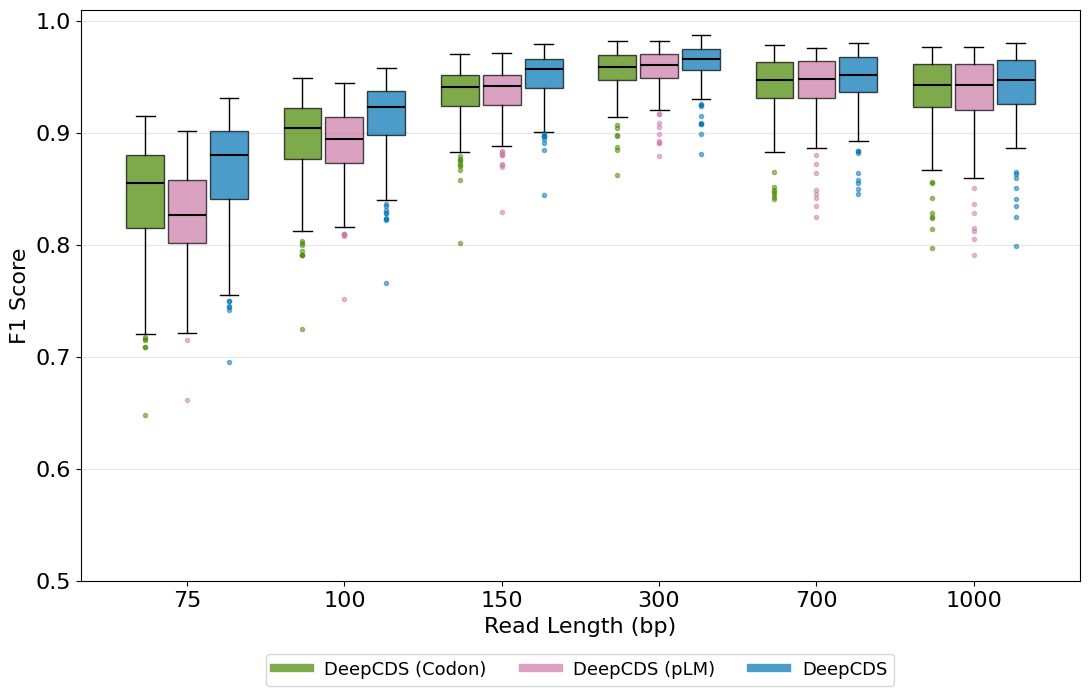

In [9]:
def plot_metric_by_read_length_boxplot(per_genome_metrics_list, read_lengths, metric_name, ylabel):
    matplotlib.rcParams['text.usetex'] = False

    active_models = [m for m in model_names
                     if any(per_genome_metrics_list[l][m][metric_name] for l in read_lengths)]
    if not active_models:
        print("No data available.")
        return

    n_active = len(active_models)
    fig, ax = plt.subplots(figsize=(11, 7))

    x_positions = np.arange(len(read_lengths))
    box_width = 0.8 / n_active
    offsets = (np.arange(n_active) - (n_active - 1) / 2) * box_width

    for k, model in enumerate(active_models):
        color = model_colors[model]
        positions, data = [], []
        for i, length in enumerate(read_lengths):
            vals = per_genome_metrics_list[length][model][metric_name]
            if vals:
                positions.append(x_positions[i] + offsets[k])
                data.append(vals)
        if not data:
            continue

        bp = ax.boxplot(
            data,
            patch_artist=True,
            positions=positions,
            widths=box_width * 0.9,
            showfliers=True,
            flierprops=dict(marker='o', markersize=3, alpha=0.5,
                            markerfacecolor=color, markeredgecolor=color),
            manage_ticks=False,
        )
        for patch in bp['boxes']:
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        for line in bp['medians']:
            line.set_color('black')
            line.set_linewidth(1.5)
        ax.plot([], [], color=color, linewidth=6, alpha=0.7,
                label=model_display_names[model])

    ax.set_xlabel('Read Length (bp)')
    ax.set_ylabel(ylabel)
    ax.set_xticks(x_positions)
    ax.set_xticklabels([str(l) for l in read_lengths])
    ax.set_ylim(0.5, 1.01)
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(bbox_to_anchor=(0.5, -0.20), loc='lower center', ncol=4)
    plt.tight_layout()
    plt.show()

plot_metric_by_read_length_boxplot(per_genome_metrics_list, read_lengths, 'f1_score', 'F1 Score')

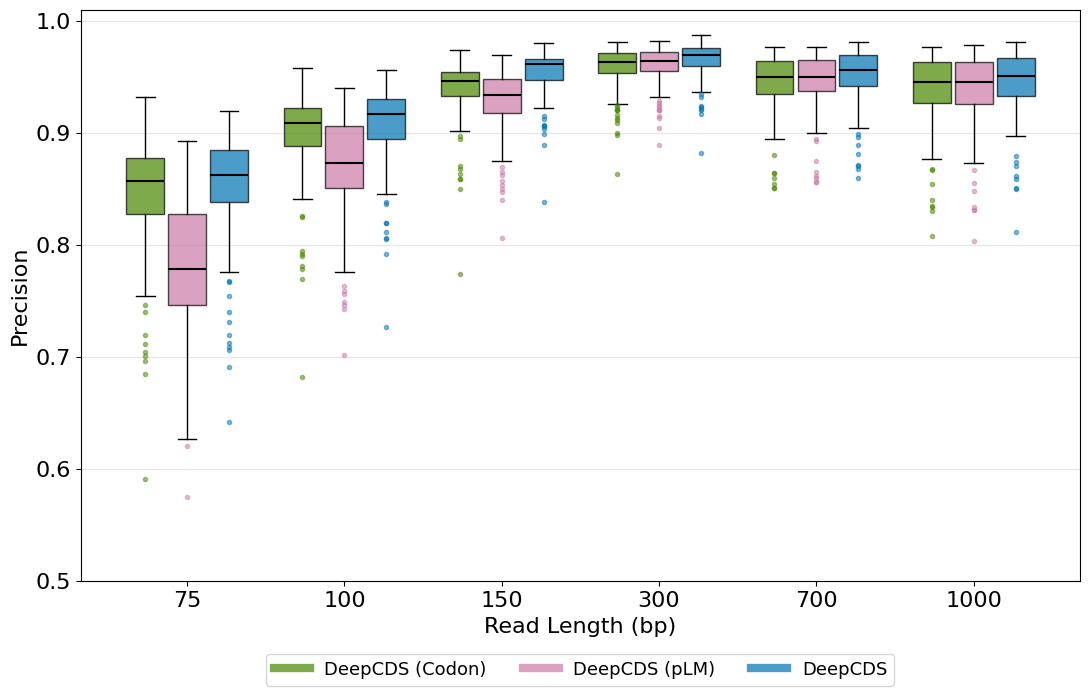

In [10]:
plot_metric_by_read_length_boxplot(per_genome_metrics_list, read_lengths, 'precision', 'Precision')

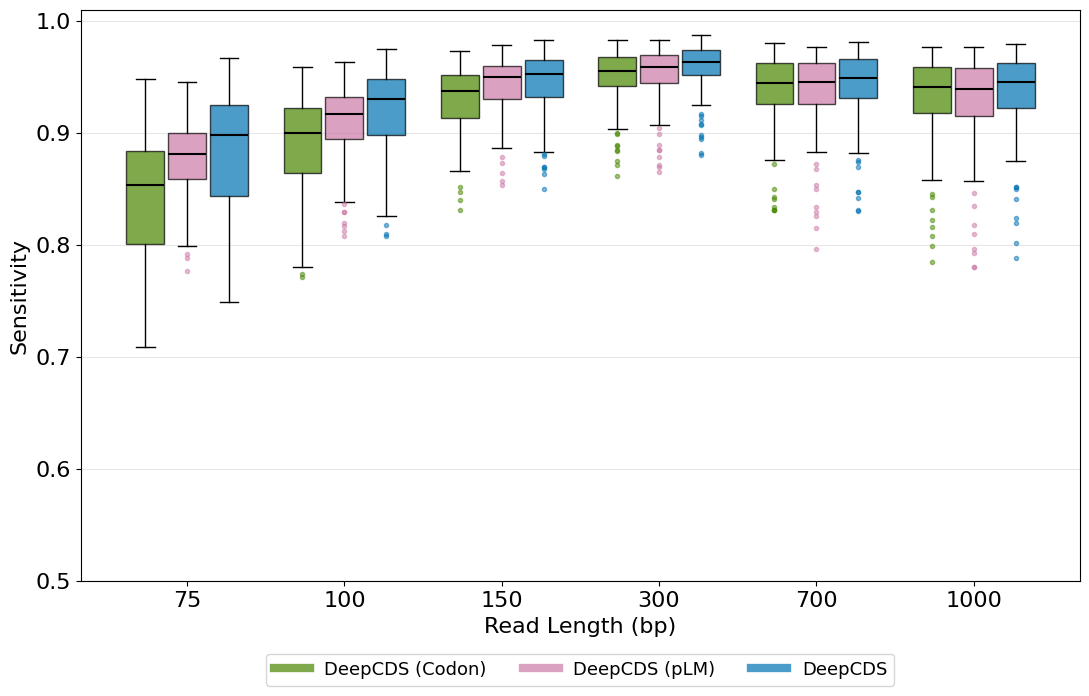

In [11]:
plot_metric_by_read_length_boxplot(per_genome_metrics_list, read_lengths, 'recall', 'Sensitivity')